In [3]:
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import box
import fiona
import os
import sklearn
import folium
import seaborn as sns
import matplotlib.pyplot as plt
from shapely.geometry import Point
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.metrics import classification_report, accuracy_score, roc_curve, auc, ConfusionMatrixDisplay
from imblearn.over_sampling import RandomOverSampler
from folium.features import GeoJsonTooltip
from sklearn.preprocessing import label_binarize, LabelEncoder, StandardScaler
from sklearn.multiclass import OneVsRestClassifier
from sklearn.calibration import CalibratedClassifierCV

DATA COLLECTING

In [4]:
gdb_path = r"E:\KULIAH SEMESTER 7\COMPUTING PROJECT\CAPSTONEPROJECT\2022_RBI25K_KAB_BANYUMAS_KUGI50_20221231.gdb"

banyumas_shp = r"E:\KULIAH SEMESTER 7\COMPUTING PROJECT\CAPSTONEPROJECT\indonesiaSHPLevel3\gadm41_IDN_3.shp"
banyumas_kab = gpd.read_file(banyumas_shp)
banyumas_kab = banyumas_kab[banyumas_kab["NAME_2"] == "Banyumas"].to_crs(epsg=32749)
banyumas_boundary = banyumas_kab.dissolve(by="NAME_2")
# banyumas_kab = gpd.read_file("batas_kecamatan_banyumas.geojson")
# banyumas_boundary = banyumas_kab.to_crs(epsg=32749) 


In [5]:
layer_hijau = [
    "HUTANLAHANTINGGI_AR_25K",
    "HUTANLAHANRENDAH_AR_25K",
    "HERBADANRUMPUT_AR_25K",
    "HUTANTANAMAN_AR_25K"
]

list_gdf = []
for layer in layer_hijau:
    gdf = gpd.read_file(gdb_path, layer=layer)
    list_gdf.append(gdf)

area_hijau = gpd.GeoDataFrame(pd.concat(list_gdf, ignore_index=True), crs=list_gdf[0].crs).to_crs(epsg=32749)


c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined
  return ogr_read(


In [6]:
layer_bangunan = ["PERUMAHAN_AR_25K", "PERMUKIMAN_AR_25K"]
bangunan_list = []

for layer in layer_bangunan:
    try:
        gdf = gpd.read_file(gdb_path, layer=layer)
        bangunan_list.append(gdf)
        print(f"Berhasil baca layer: {layer} ({len(gdf)} fitur)")
    except Exception as e:
        print(f"Gagal membaca layer {layer}: {e}")

# Gabung jadi 1 dataframe
bangunan = gpd.GeoDataFrame(
    pd.concat(bangunan_list, ignore_index=True),
    crs=bangunan_list[0].crs
).to_crs(epsg=32749)

jalan = gpd.read_file(gdb_path, layer="JALAN_LN_25K").to_crs(epsg=32749)

Berhasil baca layer: PERUMAHAN_AR_25K (291 fitur)
Berhasil baca layer: PERMUKIMAN_AR_25K (4405 fitur)


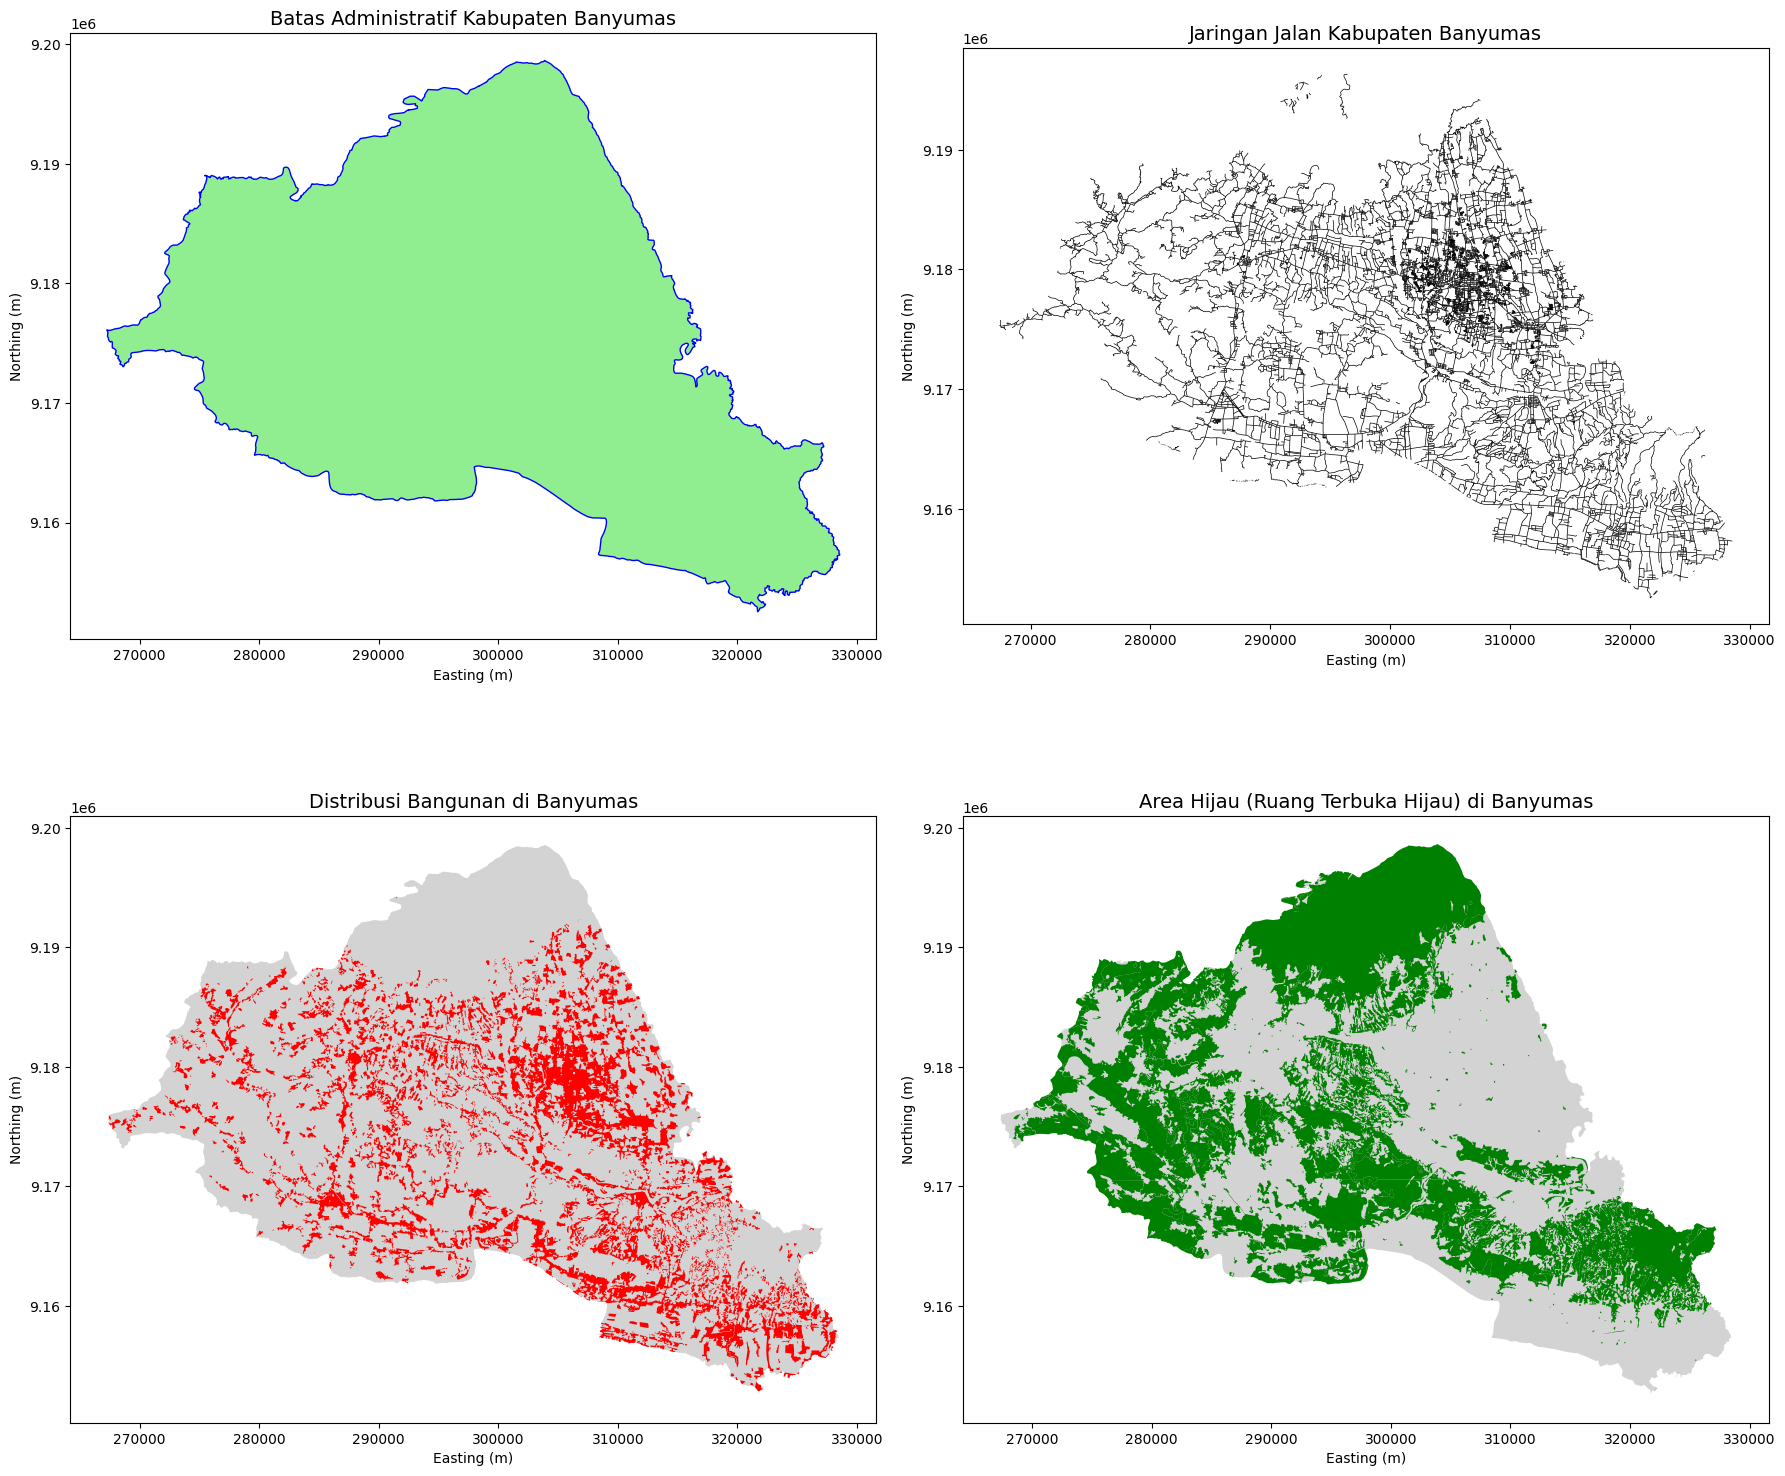

In [7]:
# Clip ke batas banyumas
jalan_bms = gpd.clip(jalan, banyumas_boundary)
bangunan_bms = gpd.clip(bangunan, banyumas_boundary)
area_hijau_bms = gpd.clip(area_hijau, banyumas_boundary)

fig, axs = plt.subplots(2, 2, figsize=(18, 16))

# Batas Administratif
banyumas_boundary.plot(ax=axs[0, 0], color="lightgreen", edgecolor="blue")
axs[0, 0].set_title("Batas Administratif Kabupaten Banyumas", fontsize=14)
axs[0, 0].set_xlabel("Easting (m)")
axs[0, 0].set_ylabel("Northing (m)")

# Jaringan Jalan
jalan_bms.plot(ax=axs[0, 1], color="black", linewidth=0.5)
axs[0, 1].set_title("Jaringan Jalan Kabupaten Banyumas", fontsize=14)
axs[0, 1].set_xlabel("Easting (m)")
axs[0, 1].set_ylabel("Northing (m)")

# Distribusi Bangunan
banyumas_boundary.plot(ax=axs[1, 0], color="lightgrey", edgecolor="white")
bangunan_bms.plot(ax=axs[1, 0], color="red", markersize=0.1)
axs[1, 0].set_title("Distribusi Bangunan di Banyumas", fontsize=14)
axs[1, 0].set_xlabel("Easting (m)")
axs[1, 0].set_ylabel("Northing (m)")

# Area Hijau
banyumas_boundary.plot(ax=axs[1, 1], color="lightgrey", edgecolor="white")
area_hijau_bms.plot(ax=axs[1, 1], color="green")
axs[1, 1].set_title("Area Hijau (Ruang Terbuka Hijau) di Banyumas", fontsize=14)
axs[1, 1].set_xlabel("Easting (m)")
axs[1, 1].set_ylabel("Northing (m)")

plt.tight_layout()
plt.show()


CONVERT TO GRID

In [8]:
minx, miny, maxx, maxy = banyumas_boundary.total_bounds
grid_size = 500

cols = np.arange(minx, maxx, grid_size)
rows = np.arange(miny, maxy, grid_size)

grid_cells = []
for x in cols:
    for y in rows:
        cell = box(x, y, x + grid_size, y + grid_size)
        grid_cells.append(cell)

grid = gpd.GeoDataFrame({"geometry": grid_cells}, crs=banyumas_boundary.crs)
grid = gpd.overlay(grid, banyumas_boundary, how="intersection")

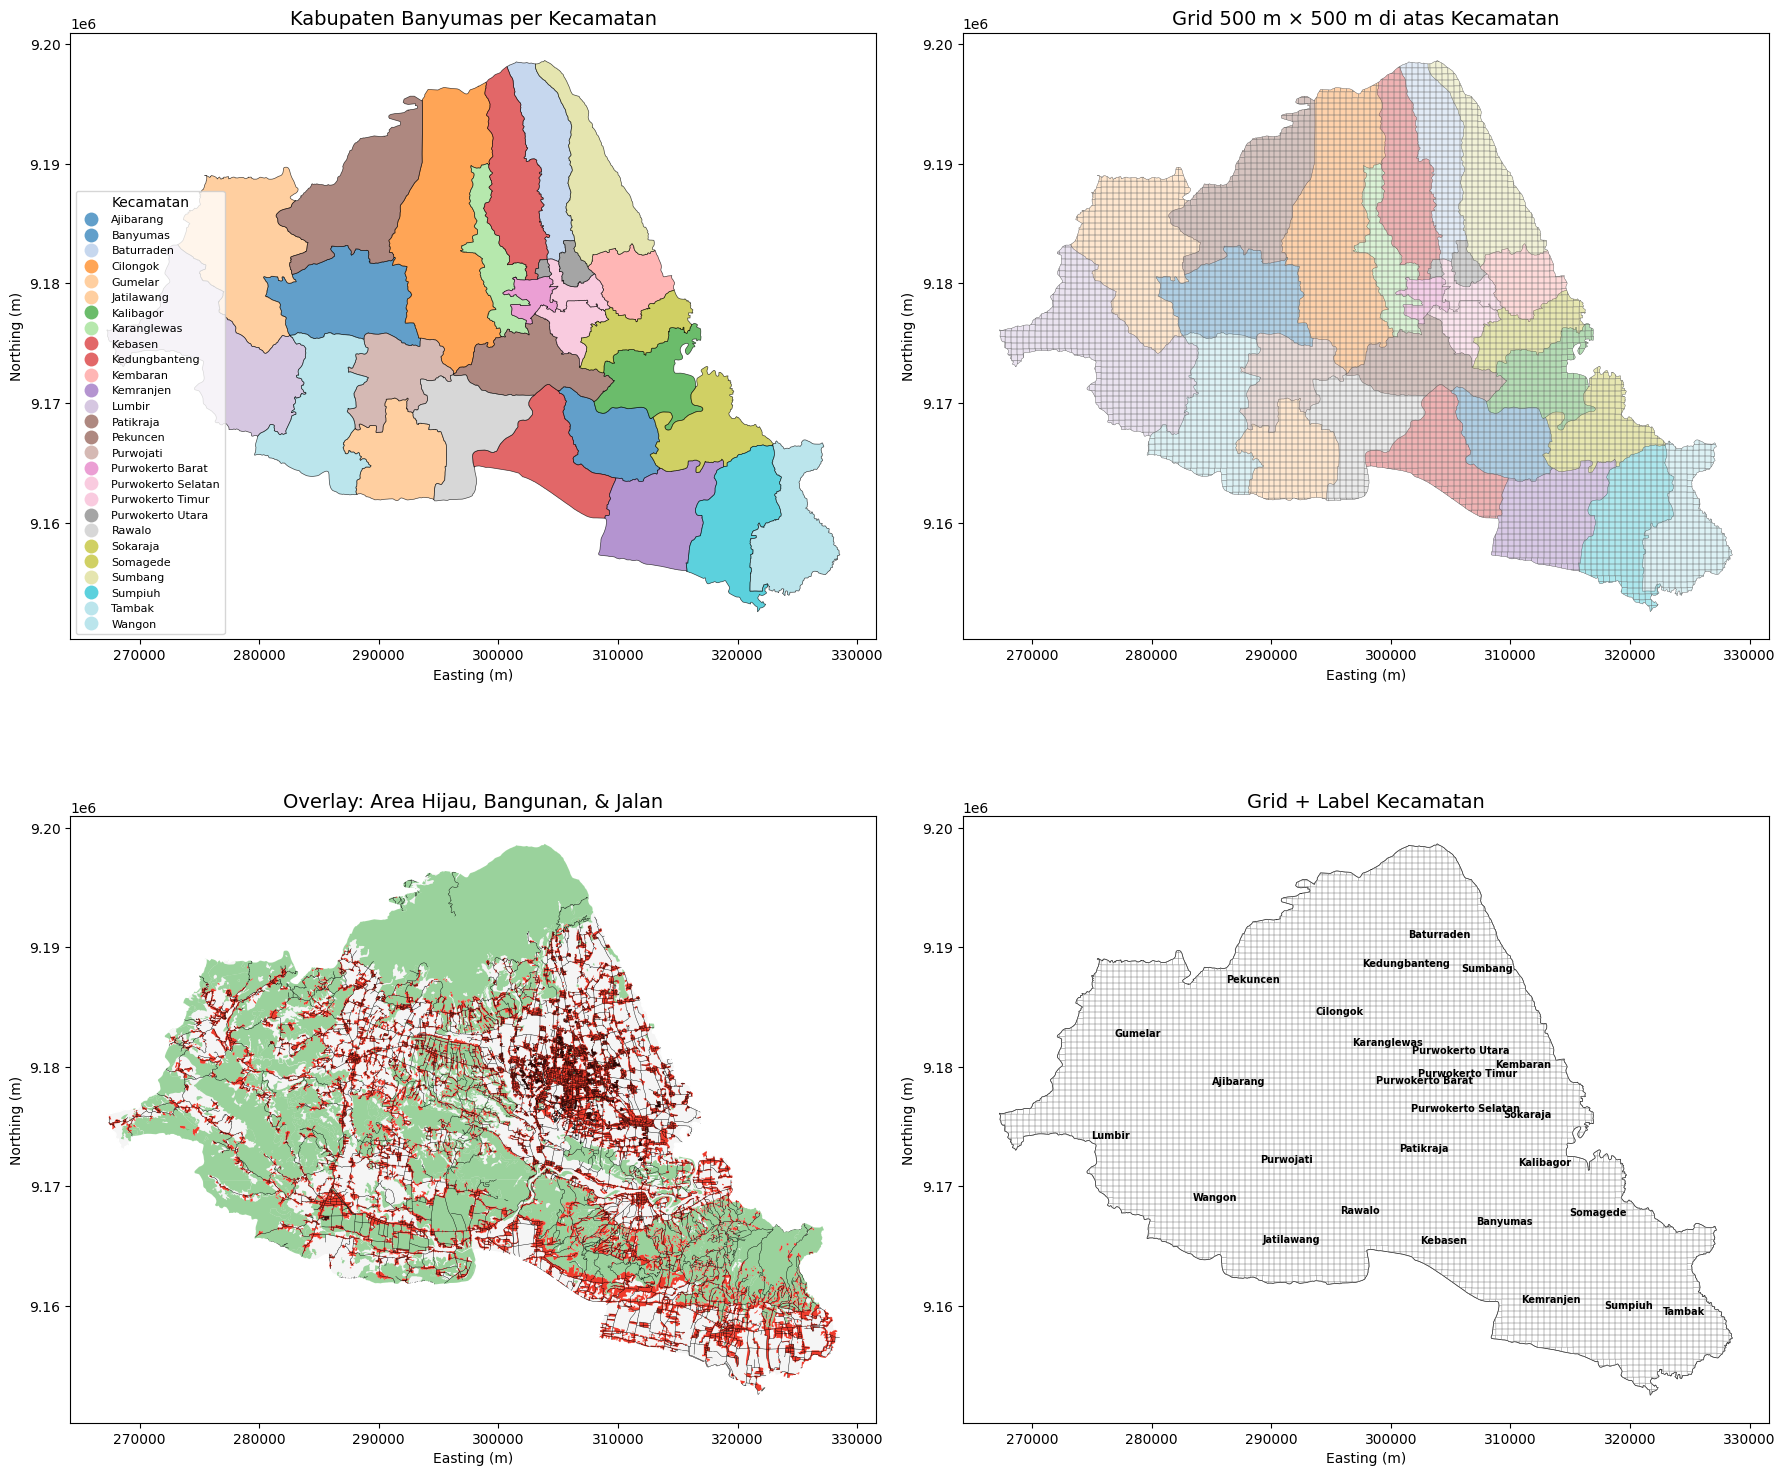

(Info) Lewati peta interaktif Folium: The field kecamatan is not available in the data. Choose from: ('GID_3', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'GID_2', 'NL_NAME_2', 'NAME_3_left', 'VARNAME_3', 'NL_NAME_3', 'TYPE_3', 'ENGTYPE_3', 'CC_3', 'HASC_3', 'grid_id', 'NAME_3_right').


In [9]:
# Pastikan kolom nama kecamatan ada. Untuk GADM level-3 biasanya "NAME_3"
KecamatanCol = "NAME_3"
assert KecamatanCol in banyumas_kab.columns, f"Kolom '{KecamatanCol}' tidak ditemukan di banyumas_kab.columns = {banyumas_kab.columns.tolist()}"

# Tambahkan grid_id dan atribut kecamatan ke setiap grid (untuk analisis/agregasi selanjutnya)
grid = grid.copy()
grid["grid_id"] = np.arange(1, len(grid) + 1)

# Spatial join: atribut kecamatan -> grid
grid_with_kec = gpd.sjoin(
    grid,
    banyumas_kab[[KecamatanCol, "geometry"]],
    how="left",
    predicate="intersects"
).rename(columns={KecamatanCol: "kecamatan"}).drop(columns=["index_right"])

# Figure 2x2
fig, axs = plt.subplots(2, 2, figsize=(18, 16))

# (A) Peta kecamatan berwarna
banyumas_kab.plot(
    ax=axs[0, 0],
    column=KecamatanCol,
    cmap="tab20",
    alpha=0.7,
    edgecolor="black",
    linewidth=0.5,
    legend=True,
    legend_kwds={"loc": "lower left", "fontsize": 8, "title": "Kecamatan"}
)
axs[0, 0].set_title("Kabupaten Banyumas per Kecamatan", fontsize=14)
axs[0, 0].set_xlabel("Easting (m)"); axs[0, 0].set_ylabel("Northing (m)")
axs[0, 0].set_aspect("equal")

# (B) Grid di atas warna kecamatan
banyumas_kab.plot(
    ax=axs[0, 1],
    column=KecamatanCol,
    cmap="tab20",
    alpha=0.35,
    edgecolor="black",
    linewidth=0.3
)
grid.boundary.plot(ax=axs[0, 1], color="dimgray", linewidth=0.2)
axs[0, 1].set_title(f"Grid {int(500)} m × {int(500)} m di atas Kecamatan", fontsize=14)
axs[0, 1].set_xlabel("Easting (m)"); axs[0, 1].set_ylabel("Northing (m)")
axs[0, 1].set_aspect("equal")

# (C) Jaringan jalan + bangunan + area hijau
banyumas_boundary.plot(ax=axs[1, 0], color="#f5f5f5", edgecolor="white")
area_hijau_bms.plot(ax=axs[1, 0], color="#74c476", alpha=0.7)     # hijau
bangunan_bms.plot(ax=axs[1, 0], color="#ef3b2c", markersize=0.2)  # merah
jalan_bms.plot(ax=axs[1, 0], color="black", linewidth=0.3)        # hitam
axs[1, 0].set_title("Overlay: Area Hijau, Bangunan, & Jalan", fontsize=14)
axs[1, 0].set_xlabel("Easting (m)"); axs[1, 0].set_ylabel("Northing (m)")
axs[1, 0].set_aspect("equal")

# (D) Grid + label kecamatan (sampling label biar tidak rame)
banyumas_boundary.plot(ax=axs[1, 1], color="white", edgecolor="black", linewidth=0.5)
grid.boundary.plot(ax=axs[1, 1], color="gray", linewidth=0.2)
# label kecamatan di centroid-nya
for _, row in banyumas_kab.iterrows():
    centroid = row.geometry.centroid
    axs[1, 1].text(centroid.x, centroid.y, str(row[KecamatanCol]),
                   fontsize=7, ha="center", va="center", weight="bold", color="black")
axs[1, 1].set_title("Grid + Label Kecamatan", fontsize=14)
axs[1, 1].set_xlabel("Easting (m)"); axs[1, 1].set_ylabel("Northing (m)")
axs[1, 1].set_aspect("equal")

plt.tight_layout()
plt.show()

# =========================
# 2) VISUALISASI INTERAKTIF (FOLIUM)
# =========================
# (opsional) aktifkan jika ingin peta zoomable disimpan sebagai HTML
try:
    import folium
    from branca.colormap import linear

    # Folium pakai WGS84 (EPSG:4326), project dulu
    banyumas_kab_4326 = banyumas_kab.to_crs(epsg=4326)
    banyumas_boundary_4326 = banyumas_boundary.to_crs(epsg=4326)
    jalan_bms_4326 = jalan_bms.to_crs(epsg=4326)
    bangunan_bms_4326 = bangunan_bms.to_crs(epsg=4326)
    area_hijau_bms_4326 = area_hijau_bms.to_crs(epsg=4326)
    grid_4326 = grid_with_kec.to_crs(epsg=4326)

    # Lokasi tengah untuk inisialisasi peta
    center = banyumas_boundary_4326.geometry.iloc[0].centroid
    m = folium.Map(location=[center.y, center.x], zoom_start=10, tiles="OpenStreetMap")

    # Layer: batas kecamatan (warna per kecamatan)
    # Buat palet diskrit untuk kecamatan
    kec_list = sorted(banyumas_kab_4326[KecamatanCol].unique())
    cmap = linear.Set3_12.scale(0, max(1, len(kec_list)-1))
    kec_to_color = {kec: cmap(i) for i, kec in enumerate(kec_list)}

    folium.GeoJson(
        banyumas_kab_4326,
        name="Kecamatan",
        style_function=lambda feat: {
            "fillColor": kec_to_color.get(feat["properties"][KecamatanCol], "#cccccc"),
            "color": "black",
            "weight": 0.7,
            "fillOpacity": 0.4,
        },
        tooltip=folium.GeoJsonTooltip(fields=[KecamatanCol], aliases=["Kecamatan"])
    ).add_to(m)

    # Layer: grid (outline tipis)
    folium.GeoJson(
        grid_4326,
        name="Grid 500m",
        style_function=lambda feat: {"color": "#666666", "weight": 0.3, "fillOpacity": 0.0},
        tooltip=folium.GeoJsonTooltip(fields=["grid_id", "kecamatan"], aliases=["Grid ID", "Kecamatan"])
    ).add_to(m)

    # Layer: area hijau
    folium.GeoJson(
        area_hijau_bms_4326,
        name="Area Hijau",
        style_function=lambda feat: {"color": "#2ca25f", "weight": 0.6, "fillColor": "#74c476", "fillOpacity": 0.5}
    ).add_to(m)

    # Layer: bangunan
    folium.GeoJson(
        bangunan_bms_4326,
        name="Bangunan",
        style_function=lambda feat: {"color": "#ef3b2c", "weight": 0.6, "fillOpacity": 0.3}
    ).add_to(m)

    # Layer: jalan
    folium.GeoJson(
        jalan_bms_4326,
        name="Jalan",
        style_function=lambda feat: {"color": "black", "weight": 1}
    ).add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)

    # Simpan
    m.save("banyumas_grid_kecamatan_interaktif.html")
    print("✅ Peta interaktif disimpan sebagai: banyumas_grid_kecamatan_interaktif.html")
except Exception as e:
    print(f"(Info) Lewati peta interaktif Folium: {e}")


FEATURE ENGINEERING

In [10]:
def hitung_fitur_per_grid(grid, gdf_area, gdf_bangunan, gdf_jalan):
    hasil = []

    for i, row in grid.iterrows():
        sel_grid = gpd.GeoDataFrame([row], crs=grid.crs)
        geom = sel_grid.geometry.iloc[0]
        
        # Area hijau
        hijau = area_hijau[area_hijau.intersects(geom)].copy()
        luas_hijau = hijau.intersection(geom).area.sum()  # m²

        # Bangunan
        bgn = bangunan[bangunan.intersects(geom)].copy()
        luas_bangunan = bgn.intersection(geom).area.sum()

        # Jalan
        jln = jalan[jalan.intersects(geom)].copy()
        panjang_jalan = jln.intersection(geom).length.sum()

        hasil.append({
            "grid_id": i,
            "luas_hijau_m2": luas_hijau,
            "luas_bangunan_m2": luas_bangunan,
            "panjang_jalan_m": panjang_jalan,
            "geometry": geom
        })

    return gpd.GeoDataFrame(hasil, crs=grid.crs)

grid_hasil = hitung_fitur_per_grid(grid, area_hijau, bangunan, jalan)

LABELING

In [11]:
# === PARAMETER GRID ===
CELL_SIZE_M = 1000                
CELL_AREA_M2 = CELL_SIZE_M**2       
CELL_AREA_KM2 = CELL_AREA_M2 / 1e6  

df = pd.read_csv(r"E:\KULIAH SEMESTER 7\COMPUTING PROJECT\CAPSTONEPROJECT\data_emisi_banyumas_kecamatan.csv")

df["road_km_per_km2"] = (df["panjang_jalan_m"] / 1000.0) / CELL_AREA_KM2
# persentase bangunan & hijau per sel
df["building_area_pct"] = (df["luas_bangunan_m2"] / CELL_AREA_M2) * 100.0
df["green_area_pct"]    = (df["luas_hijau_m2"]    / CELL_AREA_M2) * 100.0

# fitur tambahan
df["ratio_green_building"] = df["luas_hijau_m2"] / (df["luas_bangunan_m2"] + 1.0)
df["ratio_road_building"]  = df["panjang_jalan_m"] / (df["luas_bangunan_m2"] + 1.0)

def p99(x): 
    return np.nanpercentile(x, 99)

scale_road   = max(p99(df["road_km_per_km2"]), 1e-9)
scale_build  = max(p99(df["building_area_pct"]), 1e-9)
scale_green  = max(p99(df["green_area_pct"]), 1e-9)

df["road_norm"]   = (df["road_km_per_km2"]   / scale_road).clip(0, 1)
df["build_norm"]  = (df["building_area_pct"] / scale_build).clip(0, 1)
df["green_norm"]  = (df["green_area_pct"]    / scale_green).clip(0, 1)

# === SKOR EMISI ===
ALPHA, BETA, GAMMA = 0.3, 0.4, 0.3  # lebih seimbang antara bangunan dan hijau
df["emission_score"] = (ALPHA * df["road_norm"] + 
                        BETA  * df["build_norm"] - 
                        GAMMA * df["green_norm"])

# === KATEGORISASI BERDASARKAN THRESHOLD REALISTIS ===
LOW_THR  = 0.05
HIGH_THR = 0.25

def to_label_realistic(s):
    if s < LOW_THR: 
        return "Rendah"
    elif s < HIGH_THR: 
        return "Sedang"
    else: 
        return "Tinggi"

df["emission_label"] = df["emission_score"].apply(to_label_realistic)

# Cek distribusi
print(df["emission_label"].value_counts(normalize=True).mul(100).round(2))

out_base = r"E:\KULIAH SEMESTER 7\COMPUTING PROJECT\CAPSTONEPROJECT"
df.to_csv(f"{out_base}/emisi_banyumas_features_scored.csv", index=False)
print("✅ Tersimpan:", f"{out_base}/emisi_banyumas_features_scored.csv")


emission_label
Rendah    63.96
Sedang    22.00
Tinggi    14.04
Name: proportion, dtype: float64
✅ Tersimpan: E:\KULIAH SEMESTER 7\COMPUTING PROJECT\CAPSTONEPROJECT/emisi_banyumas_features_scored.csv


In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np

# ========= 0) Safety checks & persiapan =========
KecamatanCol = "NAME_3"  # ganti bila beda, misal "kecamatan"
assert KecamatanCol in banyumas_kab.columns, f"Kolom '{KecamatanCol}' tidak ada di banyumas_kab!"

# Samakan CRS dulu (harus UTM meter: EPSG:32749)
for gdf_name, gdf in [("banyumas_kab", banyumas_kab),
                      ("banyumas_boundary", banyumas_boundary),
                      ("grid", grid),
                      ("jalan_bms", jalan_bms),
                      ("bangunan_bms", bangunan_bms),
                      ("area_hijau_bms", area_hijau_bms)]:
    if gdf.crs != "EPSG:32749":
        try:
            locals()[gdf_name] = gdf.to_crs(epsg=32749)
        except Exception:
            pass  # jika sudah 32749 atau crs sama

# Pastikan grid punya id & luas sel (memperhitungkan sel terpotong di tepi)
grid = grid.copy()
grid["grid_id"] = np.arange(1, len(grid) + 1)
grid["cell_area_m2"] = grid.geometry.area

# Kaitkan kecamatan ke masing-masing grid
grid_kec = gpd.sjoin(
    grid[["grid_id", "cell_area_m2", "geometry"]],
    banyumas_kab[[KecamatanCol, "geometry"]],
    how="left",
    predicate="intersects"
).rename(columns={KecamatanCol: "kecamatan"}).drop(columns=["index_right"])

# ========= 1) Ekstraksi fitur per grid =========
# A. Luas bangunan per grid (m2)
if len(bangunan_bms) > 0:
    bangunan_clip = gpd.overlay(bangunan_bms, grid_kec[["grid_id", "geometry"]], how="intersection")
    bangunan_clip["bangunan_m2"] = bangunan_clip.geometry.area
    feat_bangunan = (bangunan_clip[["grid_id", "bangunan_m2"]]
                     .groupby("grid_id", as_index=False).sum())
else:
    feat_bangunan = pd.DataFrame({"grid_id": [], "bangunan_m2": []})

# B. Luas area hijau per grid (m2)
if len(area_hijau_bms) > 0:
    hijau_clip = gpd.overlay(area_hijau_bms, grid_kec[["grid_id", "geometry"]], how="intersection")
    hijau_clip["hijau_m2"] = hijau_clip.geometry.area
    feat_hijau = (hijau_clip[["grid_id", "hijau_m2"]]
                  .groupby("grid_id", as_index=False).sum())
else:
    feat_hijau = pd.DataFrame({"grid_id": [], "hijau_m2": []})

# C. Panjang jalan per grid (m)
if len(jalan_bms) > 0:
    jalan_clip = gpd.overlay(jalan_bms, grid_kec[["grid_id", "geometry"]], how="intersection")
    jalan_clip["jalan_m"] = jalan_clip.geometry.length
    feat_jalan = (jalan_clip[["grid_id", "jalan_m"]]
                  .groupby("grid_id", as_index=False).sum())
else:
    feat_jalan = pd.DataFrame({"grid_id": [], "jalan_m": []})

# Gabungkan semua fitur ke tabel grid
feat = (grid_kec[["grid_id", "kecamatan", "cell_area_m2"]]
        .drop_duplicates()
        .merge(feat_bangunan, on="grid_id", how="left")
        .merge(feat_hijau, on="grid_id", how="left")
        .merge(feat_jalan, on="grid_id", how="left"))
feat[["bangunan_m2", "hijau_m2", "jalan_m"]] = feat[["bangunan_m2", "hijau_m2", "jalan_m"]].fillna(0.0)

# ========= 2) Buat densitas/rasio per grid (unit: per luas sel) =========
# Catatan: cell_area_m2 bisa < 0.25 km2 karena sel terpotong tepi; maka pakai luas aktual.
feat["building_density"] = feat["bangunan_m2"] / feat["cell_area_m2"]            # proporsi area bangunan
feat["green_ratio"]      = feat["hijau_m2"]    / feat["cell_area_m2"]            # proporsi area hijau
feat["road_km_per_km2"]  = (feat["jalan_m"] / 1000.0) / (feat["cell_area_m2"] / 1e6)

# ========= 3) Skor emisi (robust p99) =========
def robust_norm(series, p=0.99):
    cap = series.quantile(p)
    if pd.isna(cap) or cap <= 0:
        return series*0  # semua 0 kalau datanya 0
    s = series.clip(upper=cap)
    s = s / cap
    return s.clip(0, 1)

# Bobot bisa kamu atur sesuai studi: jalan & bangunan menaikkan emisi, hijau menurunkan
w_road, w_building, w_green = 0.4, 0.4, 0.2
feat["score"] = (
    w_road     * robust_norm(feat["road_km_per_km2"]) +
    w_building * robust_norm(feat["building_density"]) +
    w_green    * (1 - robust_norm(feat["green_ratio"]))
)

# ========= 4) Agregasi ke tingkat kecamatan =========
kec = (feat.groupby("kecamatan", dropna=False)
       .agg(n_grid=("grid_id", "nunique"),
            mean_score=("score", "mean"),
            mean_road_km_per_km2=("road_km_per_km2", "mean"),
            mean_building_density=("building_density", "mean"),
            mean_green_ratio=("green_ratio", "mean"))
       .reset_index())

# ========= 5) Klasifikasi Normal / Sedang / Parah (berdasar tertile) =========
q1 = kec["mean_score"].quantile(1/3)
q2 = kec["mean_score"].quantile(2/3)

def label(row):
    v = row["mean_score"]
    if v <= q1:
        return "Normal"
    elif v <= q2:
        return "Sedang"
    else:
        return "Parah"

kec["kategori"] = kec.apply(label, axis=1)

# (opsional) urutkan dari paling parah
kec = kec.sort_values("mean_score", ascending=False)

# Simpan CSV
def safe_save_csv(df, filename="kecamatan_emisi_kategori.csv", out_dir=None):
    # 1) Tentukan folder output yang aman ditulis
    if out_dir is None:
        # ganti ke folder proyekmu biar rapi
        out_dir = r"E:\KULIAH SEMESTER 7\COMPUTING PROJECT\CAPSTONEPROJECT\outputs"
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    # 2) Jika file lama ada & tidak sedang terkunci, hapus; kalau terkunci, pakai nama unik
    target = out_dir / filename
    if target.exists():
        try:
            os.remove(target)
        except PermissionError:
            # masih terkunci (mis. terbuka di Excel) → pakai nama baru dengan timestamp
            ts = time.strftime("%Y%m%d_%H%M%S")
            target = out_dir / f"{Path(filename).stem}_{ts}.csv"

    # 3) Simpan dengan encoding aman
    df.to_csv(target, index=False, encoding="utf-8-sig")
    print(f"✅ Tersimpan: {target}")

# panggil fungsi ini untuk menyimpan:
safe_save_csv(kec)


In [ ]:
# =========================
# PETA INTERAKTIF FOLIUM
# =========================
import folium
from branca.colormap import linear

KecamatanCol = "NAME_3"  # kolom nama kecamatan pada banyumas_kab (GADM level-3)

# 1) Merge hasil kategori ke geometri kecamatan
gdf_kec = banyumas_kab[[KecamatanCol, "geometry"]].copy()
gdf_kec = gdf_kec.merge(
    kec.rename(columns={"kecamatan": KecamatanCol}),
    on=KecamatanCol,
    how="left"
)

# 2) Siapkan data grid + skor (optional tooltip)
grid_feat = grid.merge(
    feat[["grid_id", "kecamatan", "score"]],
    on="grid_id",
    how="left"
)

# 3) Proyeksikan ke WGS84 buat Folium
gdf_kec_4326 = gdf_kec.to_crs(epsg=4326)
grid_4326 = grid_feat.to_crs(epsg=4326)
banyumas_boundary_4326 = banyumas_boundary.to_crs(epsg=4326)
jalan_bms_4326 = jalan_bms.to_crs(epsg=4326)
bangunan_bms_4326 = bangunan_bms.to_crs(epsg=4326)
area_hijau_bms_4326 = area_hijau_bms.to_crs(epsg=4326)

# 4) Peta dasar
center = banyumas_boundary_4326.geometry.iloc[0].centroid
m = folium.Map(location=[center.y, center.x], zoom_start=10, tiles="OpenStreetMap")

# 5) Warna kategori diskrit
cat_order = ["Normal", "Sedang", "Parah"]
cat_colors = {
    "Normal": "#4daf4a",  # hijau
    "Sedang": "#ffbf00",  # kuning/amber
    "Parah":  "#e41a1c",  # merah
}
def kec_style_func(feat):
    cat = feat["properties"].get("kategori", None)
    return {
        "fillColor": cat_colors.get(cat, "#cccccc"),
        "color": "black",
        "weight": 0.8,
        "fillOpacity": 0.45
    }

# 6) Layer: Choropleth kategori kecamatan
folium.GeoJson(
    gdf_kec_4326,
    name="Kategori Kecamatan",
    style_function=kec_style_func,
    tooltip=folium.GeoJsonTooltip(
        fields=[KecamatanCol, "kategori", "mean_score",
                "mean_road_km_per_km2", "mean_building_density", "mean_green_ratio"],
        aliases=["Kecamatan", "Kategori", "Mean Score",
                 "Road km/km²", "Building density", "Green ratio"],
        localize=True
    )
).add_to(m)

# 7) Legend kategori (manual)
legend_html = """
<div style="position: fixed; bottom: 20px; left: 20px; z-index:9999; 
background: white; padding: 10px 12px; border: 1px solid #ccc; border-radius: 6px; font-size: 12px;">
<b>Kategori Emisi</b><br>
<span style="background:#e41a1c; display:inline-block; width:12px; height:12px; margin-right:6px;"></span> Parah<br>
<span style="background:#ffbf00; display:inline-block; width:12px; height:12px; margin-right:6px;"></span> Sedang<br>
<span style="background:#4daf4a; display:inline-block; width:12px; height:12px; margin-right:6px;"></span> Normal
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# 8) Layer: Grid (outline + tooltip skor)
#    (opsional: kalau gridnya sangat banyak, kamu bisa sampling untuk kinerja)
folium.GeoJson(
    grid_4326,
    name="Grid 500 m",
    style_function=lambda feat: {"color": "#666666", "weight": 0.3, "fillOpacity": 0.0},
    tooltip=folium.GeoJsonTooltip(
        fields=["grid_id", "kecamatan", "score"],
        aliases=["Grid ID", "Kecamatan", "Score"],
        localize=True
    )
).add_to(m)

# 9) Layer: Area Hijau / Bangunan / Jalan (dapat di-toggle)
folium.GeoJson(
    area_hijau_bms_4326,
    name="Area Hijau",
    style_function=lambda f: {"color": "#2ca25f", "weight": 0.6, "fillColor": "#74c476", "fillOpacity": 0.4}
).add_to(m)

folium.GeoJson(
    bangunan_bms_4326,
    name="Bangunan",
    style_function=lambda f: {"color": "#ef3b2c", "weight": 0.6, "fillOpacity": 0.2}
).add_to(m)

folium.GeoJson(
    jalan_bms_4326,
    name="Jalan",
    style_function=lambda f: {"color": "#1f1f1f", "weight": 1}
).add_to(m)

# 10) Layer control & simpan
folium.LayerControl(collapsed=False).add_to(m)
out_html = "banyumas_emisi_kategori_interaktif.html"
m.save(out_html)
print(f"✅ Peta interaktif tersimpan: {out_html}")


DATA SPLITTING

In [ ]:
if "kategori_emisi" not in df.columns and "emission_label" in df.columns:
    df = df.rename(columns={"emission_label": "kategori_emisi"})

# Pastikan kolom dasar ada
required_base = ["luas_hijau_m2", "luas_bangunan_m2", "panjang_jalan_m"]
missing_base = [c for c in required_base if c not in df.columns]
if missing_base:
    raise KeyError(f"Kolom dasar hilang: {missing_base}. Pastikan CSV dari tahap grid+join kecamatan yang benar.")

# Tipe numerik & isi NaN = 0
for c in required_base:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)

if "rasio_hijau_bangunan" not in df.columns:
    if "ratio_green_building" in df.columns:
        df["rasio_hijau_bangunan"] = pd.to_numeric(df["ratio_green_building"], errors="coerce").fillna(0)
    else:
        df["rasio_hijau_bangunan"] = df["luas_hijau_m2"] / (df["luas_bangunan_m2"] + 1.0)

if "rasio_jalan_bangunan" not in df.columns:
    if "ratio_road_building" in df.columns:
        df["rasio_jalan_bangunan"] = pd.to_numeric(df["ratio_road_building"], errors="coerce").fillna(0)
    else:
        df["rasio_jalan_bangunan"] = df["panjang_jalan_m"] / (df["luas_bangunan_m2"] + 1.0)

# Pastikan target label ada
if "kategori_emisi" not in df.columns:
    raise KeyError("Kolom target 'kategori_emisi' tidak ditemukan. Jalankan tahap labeling dulu.")

# (Opsional) buang baris tanpa kecamatan
if "kecamatan" in df.columns:
    df = df.dropna(subset=["kecamatan"]).reset_index(drop=True)

In [ ]:
# === DATA SPLITTING BY KECAMATAN ===
train_kecamatan = ["Purwokerto Selatan", "Purwokerto Barat", "Purwokerto Timur", "Baturraden", "Sokaraja"]
test_kecamatan  = ["Kalibagor", "Somagede"]

df_train = df[df["kecamatan"].isin(train_kecamatan)].copy()
df_test  = df[df["kecamatan"].isin(test_kecamatan)].copy()

# Cek minimum rows
if df_train.empty or df_test.empty:
    raise ValueError("Subset train/test kosong. Cek ejaan nama kecamatan atau distribusi datanya.")

fitur = [
    "luas_hijau_m2", "luas_bangunan_m2", "panjang_jalan_m",
    "rasio_hijau_bangunan", "rasio_jalan_bangunan"
]

# Pastikan semua fitur ada
missing_feats = [c for c in fitur if c not in df_train.columns]
if missing_feats:
    raise KeyError(f"Kolom fitur hilang di df_train: {missing_feats}")

X_train = df_train[fitur].apply(pd.to_numeric, errors="coerce").fillna(0)
y_train = df_train["kategori_emisi"].astype(str)

X_test  = df_test[fitur].apply(pd.to_numeric, errors="coerce").fillna(0)
y_test  = df_test["kategori_emisi"].astype(str)

print("Kolom fitur siap:", fitur)
print("Distribusi label TRAIN:", y_train.value_counts().to_dict())
print("Distribusi label TEST :", y_test.value_counts().to_dict())

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Gabungkan info distribusi ke dataframe
train_counts = y_train.value_counts().rename("Train")
test_counts  = y_test.value_counts().rename("Test")

distrib = pd.concat([train_counts, test_counts], axis=1).fillna(0).astype(int)
distrib_pct = distrib.div(distrib.sum(axis=0), axis=1) * 100  # persen per set

plt.figure(figsize=(8, 5))
distrib_pct.plot(kind="bar", ax=plt.gca(), color=["#42a5f5", "#66bb6a"])
plt.title("Distribusi Persentase Kategori Emisi — Train vs Test", fontsize=13)
plt.ylabel("Persentase (%)")
plt.xlabel("Kategori Emisi")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Pie Train
axes[0].pie(train_counts, labels=train_counts.index, autopct="%.1f%%", 
            colors=["#81c784", "#fff176", "#e57373"], startangle=90)
axes[0].set_title("Proporsi Label Train")

# Pie Test
axes[1].pie(test_counts, labels=test_counts.index, autopct="%.1f%%", 
            colors=["#81c784", "#fff176", "#e57373"], startangle=90)
axes[1].set_title("Proporsi Label Test")

plt.suptitle("Perbandingan Proporsi Kelas (Train vs Test)", fontsize=13)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
sns.heatmap(distrib_pct.T, annot=True, cmap="YlOrRd", fmt=".1f", linewidths=0.5)
plt.title("Heatmap Proporsi Label pada Train & Test (%)", fontsize=13)
plt.xlabel("Kategori Emisi")
plt.ylabel("Dataset")
plt.tight_layout()
plt.show()

# --- Pastikan ada label per grid ---
# Jika belum ada, buat label tertile: Normal / Sedang / Parah dari feat['score']
if "emission_label" not in feat.columns:
    q = feat["score"].quantile([1/3, 2/3])
    q1, q2 = q.iloc[0], q.iloc[1]

    def to_label(v):
        if v <= q1:   return "Normal"
        elif v <= q2: return "Sedang"
        else:         return "Parah"

    feat["emission_label"] = feat["score"].apply(to_label)

# --- Bangun df untuk plotting sebaran per kecamatan ---
# Ambil hanya kolom yang diperlukan dan buang baris tanpa kecamatan
df = feat[["kecamatan", "emission_label"]].dropna(subset=["kecamatan", "emission_label"]).copy()

# (opsional) urutkan kecamatan dari jumlah grid terbanyak biar rapi
kec_order = (
    df.groupby("kecamatan")
      .size()
      .sort_values(ascending=False)
      .index.tolist()
)

# (opsional) set urutan label biar konsisten legend/warna
label_order = ["Parah", "Sedang", "Normal"]   # atau ["Normal","Sedang","Parah"]
df["emission_label"] = pd.Categorical(df["emission_label"], categories=label_order, ordered=True)


plt.figure(figsize=(10, 6))
sns.countplot(data=df, y="kecamatan", hue="emission_label", palette="RdYlGn_r")
plt.title("Distribusi Label Emisi per Kecamatan", fontsize=13)
plt.xlabel("Jumlah Grid")
plt.ylabel("Kecamatan")
plt.legend(title="Kategori Emisi")
plt.tight_layout()
plt.show()


In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import box
from pathlib import Path
import re
from typing import List, Tuple, Optional, Iterable

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report

KONFIGURASI PATH

In [ ]:
GDB_BANYUMAS = r"E:/KULIAH SEMESTER 7/COMPUTING PROJECT/CAPSTONEPROJECT/2022_RBI25K_KAB_BANYUMAS_KUGI50_20221231.gdb"
GDB_JAKPUS   = r"E:/KULIAH SEMESTER 7/COMPUTING PROJECT/CAPSTONEPROJECT/KotaAdm.JakartaPusat/2022_RBI25K_JAKPUS.gdb"
GDB_YOGYA    = r"E:/KULIAH SEMESTER 7/COMPUTING PROJECT/CAPSTONEPROJECT/KotaYogyakarta/KOTA YOGYAKARTA/2022_RBI25K_KOTA_YOGYAKARTA_KUGI50_20221231.gdb"

GADM_L3      = r"E:/KULIAH SEMESTER 7/COMPUTING PROJECT/CAPSTONEPROJECT/indonesiaSHPLevel3/gadm41_IDN_3.shp"
EXPORT_DIR   = r"E:/KULIAH SEMESTER 7/COMPUTING PROJECT/CAPSTONEPROJECT/outputs"
Path(EXPORT_DIR).mkdir(parents=True, exist_ok=True)

In [ ]:
def list_layers_safe(gdb_path: str) -> List[str]:
    import fiona
    return list(fiona.listlayers(gdb_path))

def available(gdb_path: str, names: Iterable[str]) -> List[str]:
    avail = set(list_layers_safe(gdb_path))
    return [n for n in names if n in avail]

def pick_road_layer_with_geom(gdb_path: str, candidates: List[str]) -> Optional[str]:
    avail = list_layers_safe(gdb_path)
    for name in candidates:
        if name in avail:
            try:
                g = gpd.read_file(gdb_path, layer=name, rows=1)
                if not g.empty and g.geometry.notna().any() and g.geometry.iloc[0].geom_type in [
                    "LineString","MultiLineString","Polygon","MultiPolygon"
                ]:
                    return name
            except Exception:
                pass
    for ly in avail:
        if "JALAN" in ly.upper() and "_LN_" in ly.upper():
            return ly
    return None

def read_union_layers(gdb_path: str, layers: List[str], target_epsg: int) -> gpd.GeoDataFrame:
    frames = []
    for ly in layers:
        try:
            g = gpd.read_file(gdb_path, layer=ly)
            if not g.empty and g.geometry.notna().any():
                frames.append(g)
                print(f"  ✓ union add: {ly} ({len(g)} fitur)")
            else:
                print(f"  ⚠︎ kosong/geometri null: {ly}")
        except Exception as e:
            print(f"  ⚠︎ gagal baca {ly}: {e}")
    if not frames:
        return gpd.GeoDataFrame(geometry=[], crs="EPSG:4326").to_crs(epsg=target_epsg)
    gdf = pd.concat(frames, ignore_index=True)
    gdf = gpd.GeoDataFrame(gdf, geometry="geometry", crs=frames[0].crs).to_crs(epsg=target_epsg)
    gdf = gdf[gdf.is_valid]
    return gdf

In [ ]:
ROAD_CANDS  = ["JALAN_LN_25K", "TRANSPORTASI_JALAN_LN", "JALAN_LN", "JALAN_LNRS"]
BUILD_CANDS_ALL = [
    "BANGUNAN_AR","PERMUKIMAN_AR_25K","PERUMAHAN_AR_25K",
    "NIAGA_AR_25K","INDUSTRI_AR_25K","INDUSTRIPARIWISATA_AR_25K",
    "PENDIDIKAN_AR_25K","ARENAOLAHRAGA_AR_25K"
]
GREEN_CANDS_ALL = [
    "TUTUPAN_LAHAN_AR","HUTANTANAMAN_AR_25K","HERBADANRUMPUT_AR_25K",
    "SAWAH_AR_25K","TAMAN_AR_25K","KEBUN_AR_25K"
]

In [ ]:
def features_from_rbi_multi(aoi_wgs84: gpd.GeoDataFrame,
                            gdb_path: str,
                            road_layer: str,
                            building_layers: List[str],
                            green_layers: List[str],
                            cell_size: int = 1000) -> gpd.GeoDataFrame:
    epsg = guess_utm_epsg_south(aoi_wgs84)
    aoi  = aoi_wgs84.to_crs(epsg)
    roads = gpd.read_file(gdb_path, layer=road_layer).to_crs(epsg=epsg) if road_layer else None
    print("  [BUILD-UP] union layers …")
    builds = read_union_layers(gdb_path, building_layers, epsg)
    print("  [GREEN]    union layers …")
    green  = read_union_layers(gdb_path, green_layers, epsg)
    grid = make_grid(aoi, cell_size=cell_size)
    grid = length_in_grid(roads,  grid, out_col="road_km")
    grid = area_in_grid(builds,  grid, out_col="building_m2")
    grid = area_in_grid(green,   grid, out_col="green_m2")
    grid["road_km_per_km2"]   = grid["road_km"] / grid["km2"]
    grid["building_area_pct"] = (grid["building_m2"] / (grid["km2"] * 1e6)) * 100.0
    grid["green_area_pct"]    = (grid["green_m2"]    / (grid["km2"] * 1e6)) * 100.0
    return grid[["geometry","km2","road_km_per_km2","building_area_pct","green_area_pct"]].copy()

In [ ]:
def load_aoi_from_gadm(gadm_l3_path: str):
    adm = gpd.read_file(gadm_l3_path)
    aoi_bms = adm[(adm["NAME_2"] == "Banyumas")].dissolve(by="NAME_2").to_crs(4326)
    aoi_jkt = adm[(adm["NAME_2"].str.contains("Jakarta Pusat", case=False, na=False))].dissolve(by="NAME_2").to_crs(4326)
    if aoi_jkt.empty:
        aoi_jkt = adm[(adm["NAME_1"].str.contains("Jakarta", case=False, na=False)) &
                      (adm["NAME_2"].str.contains("Pusat",   case=False, na=False))].dissolve(by="NAME_2").to_crs(4326)
    aoi_ygy = adm[(adm["NAME_2"].str.contains("Yogyakarta", case=False, na=False))].dissolve(by="NAME_2").to_crs(4326)
    if aoi_bms.empty or aoi_jkt.empty or aoi_ygy.empty:
        raise ValueError("Gagal memuat AOI dari GADM. Cek kolom NAME_1/NAME_2.")
    return aoi_bms, aoi_jkt, aoi_ygy

In [ ]:
def prepare_city_features(city: str, aoi_wgs84: gpd.GeoDataFrame, gdb_path: str) -> gpd.GeoDataFrame:
    print(f"\n== Ekstraksi fitur {city} ==")
    road = pick_road_layer_with_geom(gdb_path, ROAD_CANDS)
    if not road:
        raise ValueError(f"[{city}] Layer jalan tidak ditemukan di {Path(gdb_path).name}.")
    bld_layers = available(gdb_path, BUILD_CANDS_ALL)
    if not bld_layers:
        raise ValueError(f"[{city}] Layer built-up tidak ditemukan di {Path(gdb_path).name}.")
    green_layers = available(gdb_path, GREEN_CANDS_ALL)
    if not green_layers:
        raise ValueError(f"[{city}] Layer hijau tidak ditemukan di {Path(gdb_path).name}.")
    print(f"  [ROAD]     {road}")
    print(f"  [BUILD-UP] {bld_layers}")
    print(f"  [GREEN]    {green_layers}")
    feat = features_from_rbi_multi(aoi_wgs84, gdb_path, road, bld_layers, green_layers, cell_size=1000)
    feat["city"] = city.replace(" ", "")
    return feat

In [ ]:
def prepare_city_features(city: str, aoi_wgs84: gpd.GeoDataFrame, gdb_path: str) -> gpd.GeoDataFrame:
    print(f"\n== Ekstraksi fitur {city} ==")
    road = pick_road_layer_with_geom(gdb_path, ROAD_CANDS)
    if not road:
        raise ValueError(f"[{city}] Layer jalan tidak ditemukan di GDB {Path(gdb_path).name}.")

    bld_layers = available(gdb_path, BUILD_CANDS_ALL)
    if not bld_layers:
        raise ValueError(f"[{city}] Layer built-up tidak ditemukan di GDB {Path(gdb_path).name}.")

    green_layers = available(gdb_path, GREEN_CANDS_ALL)
    if not green_layers:
        raise ValueError(f"[{city}] Layer hijau tidak ditemukan di GDB {Path(gdb_path).name}.")

    print(f"  [ROAD]     {road}")
    print(f"  [BUILD-UP] {bld_layers}")
    print(f"  [GREEN]    {green_layers}")

    feat = features_from_rbi_multi(aoi_wgs84, gdb_path, road, bld_layers, green_layers, cell_size=1000)
    feat["city"] = city.replace(" ", "")
    return feat

In [ ]:
def main():
    AOI_BMS, AOI_JKT, AOI_YGY = load_aoi_from_gadm(GADM_L3)
    bms_feat = prepare_city_features("Banyumas",      AOI_BMS, GDB_BANYUMAS)
    jkt_feat = prepare_city_features("Jakarta Pusat", AOI_JKT, GDB_JAKPUS)
    ygy_feat = prepare_city_features("Yogyakarta",    AOI_YGY, GDB_YOGYA)

    # Samakan CRS dan export
    target_crs = "EPSG:4326"
    bms_feat = bms_feat.to_crs(target_crs)
    jkt_feat = jkt_feat.to_crs(target_crs)
    ygy_feat = ygy_feat.to_crs(target_crs)

    # Export GeoPackage per kota
    out_gpkg = Path(EXPORT_DIR) / "emission_features_per_city.gpkg"
    try:
        bms_feat.to_file(out_gpkg, layer="Banyumas", driver="GPKG")
        jkt_feat.to_file(out_gpkg, layer="JakartaPusat", driver="GPKG")
        ygy_feat.to_file(out_gpkg, layer="Yogyakarta", driver="GPKG")
        print(f"[EXPORT] GeoPackage disimpan: {out_gpkg}")
    except Exception as e:
        print(f"[EXPORT] GeoPackage di-skip (error: {e})")

    # CSV gabungan (tanpa geometry)
    all_feat = pd.concat([bms_feat, jkt_feat, ygy_feat], ignore_index=True)
    (Path(EXPORT_DIR) / "tables").mkdir(exist_ok=True, parents=True)
    all_feat.drop(columns="geometry").to_csv(Path(EXPORT_DIR) / "tables/all_features_no_label.csv", index=False)
    bms_feat.drop(columns="geometry").to_csv(Path(EXPORT_DIR) / "tables/banyumas_features_no_label.csv", index=False)
    jkt_feat.drop(columns="geometry").to_csv(Path(EXPORT_DIR) / "tables/jakpus_features_no_label.csv", index=False)
    ygy_feat.drop(columns="geometry").to_csv(Path(EXPORT_DIR) / "tables/yogya_features_no_label.csv", index=False)

    # Ringkasan
    print("\n[SUMMARY]")
    for name, df in [("Banyumas", bms_feat), ("JakartaPusat", jkt_feat), ("Yogyakarta", ygy_feat)]:
        print(f"  {name}: {len(df)} grid")
        print(df[["road_km_per_km2","building_area_pct","green_area_pct"]].describe().round(3))
        print("-"*40)

if __name__ == "__main__":
    main()

In [ ]:
if __name__ == "__main__":
    main()

In [ ]:
# ============== EKSTRAK FITUR per KOTA (ROBUST TANPA UBAH FUNGSI LAIN) ==============

def pick_first_existing_layer(gdb_path, candidates):
    avail = set(list_layers(gdb_path))
    for name in candidates:
        if name in avail:
            return name
    return None

# Kandidat per tema (urutkan dari yang paling ideal)
ROAD_CANDS  = [
    "JALAN_LN_25K", "TRANSPORTASI_JALAN_LN", "JALAN_LN", "JALAN_LNRS"
]
# Proxy bangunan: pakai layer built-up permukiman/niaga/industri dst kalau BANGUNAN_AR tidak ada
BUILD_CANDS = [
    "BANGUNAN_AR",
    "PERMUKIMAN_AR_25K", "PERUMAHAN_AR_25K",
    "NIAGA_AR_25K", "INDUSTRI_AR_25K", "INDUSTRIPARIWISATA_AR_25K",
    "PENDIDIKAN_AR_25K", "ARENAOLAHRAGA_AR_25K"
]
# Hijau: pilih satu layer hijau yang tersedia (kalau mau gabung banyak layer hijau, nanti bisa kita upgrade)
GREEN_CANDS = [
    "TUTUPAN_LAHAN_AR",  # jika ada
    "HUTANTANAMAN_AR_25K", "HERBADANRUMPUT_AR_25K", "SAWAH_AR_25K",
    "TAMAN_AR_25K", "KEBUN_AR_25K"
]

def resolve_layers_simple(city, gdb_path, ly_road, ly_bldg, ly_green):
    # Jika user sudah isi dan ada, pakai itu; jika tidak, pilih dari kandidat
    r = ly_road  if ly_road  in set(list_layers(gdb_path)) else pick_first_existing_layer(gdb_path, ROAD_CANDS)
    b = ly_bldg  if ly_bldg  in set(list_layers(gdb_path)) else pick_first_existing_layer(gdb_path, BUILD_CANDS)
    g = ly_green if ly_green in set(list_layers(gdb_path)) else pick_first_existing_layer(gdb_path, GREEN_CANDS)

    print(f"[{city}] memakai layer -> road={r}, building={b}, green={g}")
    if not (r and b and g):
        # Cetak daftar layer supaya kamu bisa cek cepat
        print(f"[{city}] Layer masih ada yang None. Daftar layer tersedia:\n{list_layers(gdb_path)}")
        raise ValueError(f"[{city}] Tidak dapat menentukan semua layer (road/building/green). Harap cek nama layer.")
    return r, b, g

print("== Ekstraksi fitur Banyumas ==")
r,b,g = resolve_layers_simple("Banyumas", GDB_BANYUMAS, LY_ROAD_BMS, LY_BUILD_BMS, LY_GREEN_BMS)
bms_feat = features_from_rbi(AOI_BANYUMAS, GDB_BANYUMAS, r, b, g)
bms_feat["city"] = "Banyumas"

print("== Ekstraksi fitur Jakarta Pusat ==")
r,b,g = resolve_layers_simple("Jakarta Pusat", GDB_JAKPUS, LY_ROAD_JKT, LY_BUILD_JKT, LY_GREEN_JKT)
jkt_feat = features_from_rbi(AOI_JAKPUS, GDB_JAKPUS, r, b, g)
jkt_feat["city"] = "JakartaPusat"

print("== Ekstraksi fitur Kota Yogyakarta ==")
r,b,g = resolve_layers_simple("Yogyakarta", GDB_YOGYA, LY_ROAD_YGY, LY_BUILD_YGY, LY_GREEN_YGY)
ygy_feat = features_from_rbi(AOI_YOGYA, GDB_YOGYA, r, b, g)
ygy_feat["city"] = "Yogyakarta"


In [ ]:
# Labelkan dengan ambang Banyumas
thr = derive_thresholds_from_banyumas(bms_feat, strategy="quantile")
for df in (bms_feat, jkt_feat, ygy_feat):
    df["label"] = df.apply(lambda r: rule_based_label(r, thr), axis=1)


In [ ]:
# Gabungkan & siapkan data ML
# -- Samakan CRS dulu (biar bisa concat)
target_crs = "EPSG:4326"
bms_feat = bms_feat.to_crs(target_crs)
jkt_feat = jkt_feat.to_crs(target_crs)
ygy_feat = ygy_feat.to_crs(target_crs)

all_feat = pd.concat([bms_feat, jkt_feat, ygy_feat], ignore_index=True)

# (opsional) sanity check kolom
req_cols = {"road_km_per_km2","building_area_pct","green_area_pct","label"}
missing = req_cols - set(all_feat.columns)
if missing:
    raise ValueError(f"Kolom wajib hilang: {missing}. Pastikan labeling sudah dibuat sebelum concat.")

X = all_feat[["road_km_per_km2","building_area_pct","green_area_pct"]].copy()
y = all_feat["label"].copy()

# Split stratified
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Balancing khusus TRAIN
ros = RandomOverSampler(random_state=42)
X_tr_bal, y_tr_bal = ros.fit_resample(X_tr, y_tr)


In [ ]:
# Pipeline SVM + GridSearchCV
pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("svm", SVC(kernel="rbf", class_weight="balanced", probability=True))
])

param_grid = {
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", 0.1, 0.01, 0.001]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gs = GridSearchCV(pipe, param_grid, scoring="accuracy", cv=cv, n_jobs=-1, verbose=1)
gs.fit(X_tr_bal, y_tr_bal)

print("\n[BEST PARAMS]", gs.best_params_)
print("[CV BEST ACC]", gs.best_score_)

y_pred = gs.predict(X_te)
print("\n=== TEST REPORT ===")
print(classification_report(y_te, y_pred))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="muted", font_scale=1.1)

#Visualisasi distribusi kategori
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Sebelum undersampling
sns.countplot(y=y_train, ax=axes[0], order=y_train.value_counts().index)
axes[0].set_title("Distribusi Kategori Emisi Sebelum Undersampling")
axes[0].set_xlabel("Jumlah Sampel")
axes[0].set_ylabel("Kategori Emisi")

# Sesudah undersampling
#sns.countplot(y=y_resampled, ax=axes[1], order=y_resampled.value_counts().index)
# axes[1].set_title("Distribusi Kategori Emisi Sesudah Undersampling")
# axes[1].set_xlabel("Jumlah Sampel")
# axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


plt.figure(figsize=(8,6))
corr = df[[
    "luas_hijau_m2", "luas_bangunan_m2", "panjang_jalan_m",
    "rasio_hijau_bangunan", "rasio_jalan_bangunan", "emisi_score"
]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Heatmap Korelasi Antar Fitur")
plt.show()


plt.figure(figsize=(10,6))
sns.boxplot(x="kategori_emisi", y="emisi_score", data=df, palette="Set2")
plt.title("Sebaran Skor Emisi Berdasarkan Kategori")
plt.xlabel("Kategori Emisi")
plt.ylabel("Nilai Emisi Score")
plt.show()


sns.pairplot(
    df.sample(min(500, len(df))),  # ambil sebagian data biar cepat
    vars=["luas_hijau_m2", "luas_bangunan_m2", "panjang_jalan_m", "emisi_score"],
    hue="kategori_emisi",
    palette="husl",
    diag_kind="kde"
)
plt.suptitle("Hubungan Antar Variabel dan Kategori Emisi", y=1.02)
plt.show()


CHECK THE CODE

In [ ]:
# Bagi skor emisi ke dalam 3 kategori: normal, sedang, parah (pakai quantile)

# Hitung batas quantile
q1 = df["emisi_score"].quantile(0.33)
q2 = df["emisi_score"].quantile(0.66)

# Fungsi untuk memberi label berdasarkan nilai emisi
def label_emisi(score):
    if score <= q1:
        return "normal"
    elif score <= q2:
        return "sedang"
    else:
        return "parah"

# Terapkan fungsi pada kolom emisi_score
df["kategori_emisi"] = df["emisi_score"].apply(label_emisi)

# Simpan hasil ke file baru
df.to_csv("data_emisi_grid_banyumas_labeled.csv", index=False)

print("✅ Data dengan label kategori emisi tersimpan di: data_emisi_grid_banyumas_labeled.csv")


In [ ]:
# Label encoding
le = LabelEncoder()
y_resampled_encoded = le.fit_transform(y_resampled)
y_test_encoded = le.transform(y_test)

classes = le.classes_  # ['normal', 'parah', 'sedang']
class_indices = list(range(len(classes)))  # [0, 1, 2]

DATA SPLITING DAN OVERSAMPLING

In [ ]:
# df_before = pd.DataFrame(X_train, columns=fitur)
# df_before["kategori_emisi"] = y_train.values
# df_before["status"] = "Sebelum Oversampling"

# df_after = pd.DataFrame(X_resampled, columns=fitur)
# df_after["kategori_emisi"] = y_resampled.values
# df_after["status"] = "Setelah Oversampling"

# fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# # Sebelum normalisasi
# sns.countplot(data=df_before, x="kategori_emisi", palette="Blues", ax=axes[0])
# axes[0].set_title("Sebelum Oversampling")
# axes[0].set_xlabel("Kategori Emisi")
# axes[0].set_ylabel("Jumlah Data")
# axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# # Setelah normalisasi
# sns.countplot(data=df_after, x="kategori_emisi", palette="Greens", ax=axes[1])
# axes[1].set_title("Setelah Oversampling")
# axes[1].set_xlabel("Kategori Emisi")
# axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# plt.suptitle("Distribusi Jumlah Data per Kategori Emisi", fontsize=14)
# plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.show()

TRAINING MODEL

In [ ]:
best_params = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf', 'linear']
}

grid = GridSearchCV(SVC(probability=True), best_params, cv=3)
grid.fit(X_resampled, y_resampled_encoded)

print("Best Params:", grid.best_params_)

calibrated_model = CalibratedClassifierCV(grid.best_estimator_, cv=3, method="isotonic")
calibrated_model.fit(X_resampled, y_resampled_encoded)

# PREDIKSI DAN EVALUASI

y_pred = calibrated_model.predict(X_test)
y_score = calibrated_model.predict_proba(X_test)

# Akurasi keseluruhan
accuracy = accuracy_score(y_test_encoded, y_pred)
print(f"\n✅ Akurasi Prediksi Keseluruhan: {accuracy:.4f} ({accuracy*100:.2f}%)\n")

# Classification Report
print("📋 Classification Report:")
print(classification_report(y_test_encoded, y_pred, target_names=classes))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test_encoded, y_pred, display_labels=classes, cmap="Blues", xticks_rotation=45
)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# DISTRIBUSI PROBABILITAS KELAS TERTINGGI (Tinggi/Parah)

print("Daftar kelas:", classes)

if "Tinggi" in classes or "tinggi" in classes:
    target_label = "Tinggi" if "Tinggi" in classes else "tinggi"
    parah_index = list(classes).index(target_label)
    
    probs = y_score[:, parah_index]

    mask_parah = (y_test_encoded == parah_index)
    mask_non_parah = (y_test_encoded != parah_index)

    sns.histplot(probs[mask_parah], color='red', label=f"{target_label} (benar)", bins=20, kde=True)
    sns.histplot(probs[mask_non_parah], color='gray', label="bukan "+target_label, bins=20, kde=True)
    plt.axvline(0.5, color='blue', linestyle='--', label="threshold = 0.5")
    plt.title(f"Distribusi Probabilitas Prediksi Kelas '{target_label}'")
    plt.xlabel(f"predict_proba untuk kelas '{target_label}'")
    plt.ylabel("Jumlah")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Kelas 'Tinggi' tidak ditemukan di daftar classes:", classes)

hasil_prediksi = pd.DataFrame(X_test, columns=fitur)
hasil_prediksi["kategori_asli"] = [classes[i] for i in y_test_encoded]
hasil_prediksi["kategori_prediksi"] = [classes[i] for i in y_pred]
hasil_prediksi["akurasi_benar"] = (hasil_prediksi["kategori_asli"] == hasil_prediksi["kategori_prediksi"])
hasil_prediksi["probabilitas_prediksi_tinggi"] = y_score[:, list(classes).index("Tinggi") if "Tinggi" in classes else list(classes).index("tinggi")]

output_path = r"E:\KULIAH SEMESTER 7\COMPUTING PROJECT\CAPSTONEPROJECT\hasil_prediksi_SVM.csv"
hasil_prediksi.to_csv(output_path, index=False)
print(f"✅ Hasil prediksi disimpan ke: {output_path}")



VISUALISASI ROC

In [ ]:
threshold = 0.3

print(f"\n Evaluasi Binary Manual + ROC Curve per Kelas (threshold = {threshold}):\n")

plt.figure(figsize=(8, 6))
colors = ['green', 'orange', 'red']
fpr = dict()
tpr = dict()
roc_auc = dict()

for i, label in enumerate(classes):
    proba = y_score[:, i]

    # ROC Curve
    y_true_binary = np.where(y_test_encoded == i, 1, 0)  # 1 = target, 0 = lainnya
    fpr[i], tpr[i], _ = roc_curve(y_true_binary, proba)
    roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f"ROC kelas '{label}' (AUC = {roc_auc[i]:.2f})")

    # Evaluasi threshold binary manual
    y_pred_manual = np.where(proba >= threshold, label, f"bukan_{label}")
    y_true_label = np.where(y_test_encoded == i, label, f"bukan_{label}")

    print(f"🟨 Kelas '{label}' vs bukan_{label}")
    print(classification_report(y_true_label, y_pred_manual))

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve per Kelas (One vs Rest)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Gabung prediksi
df_test["prediksi_kategori"] = y_pred

df_test.to_csv(r"E:\KULIAH SEMESTER 7\COMPUTING PROJECT\CAPSTONEPROJECT\hasil_prediksi_SVM.csv", index=False)
print(" Prediksi disimpan ke: hasil_prediksi_SVM.csv")

In [ ]:
def rekap_prediksi_semua_kecamatan(df_grid, model):
    semua_kecamatan = df_grid["kecamatan"].unique()
    hasil_list = []

    luas_grid_m2 = 1_000_000

    df_grid["rasio_hijau_bangunan"] = df_grid["luas_hijau_m2"] / (df_grid["luas_bangunan_m2"] + 1)
    df_grid["rasio_jalan_bangunan"] = df_grid["panjang_jalan_m"] / (df_grid["luas_bangunan_m2"] + 1)

    for kec in semua_kecamatan:
        data_kec = df_grid[df_grid["kecamatan"] == kec]

        if data_kec.empty:
            continue

        X = data_kec[["luas_hijau_m2", "luas_bangunan_m2", "panjang_jalan_m", "rasio_hijau_bangunan", "rasio_jalan_bangunan"]]
        pred = model.predict(X)

        data_kec = data_kec.copy()
        data_kec["prediksi_kategori"] = pred

        # Rata-rata hasil
        kategori_dominan = data_kec["prediksi_kategori"].mode()[0]
        skor_emisi = data_kec["emisi_score"].mean() if "emisi_score" in data_kec.columns else None
        kepadatan_jalan = (data_kec["panjang_jalan_m"] / luas_grid_m2).mean() * 1000
        kepadatan_bangunan = (data_kec["luas_bangunan_m2"] / luas_grid_m2).mean()
        persentase_hijau = (data_kec["luas_hijau_m2"] / luas_grid_m2).mean() * 100

        hasil_list.append({
            "kecamatan": kec,
            "kategori_emisi": kategori_dominan,
            "rata_skor_emisi": skor_emisi,
            "kepadatan_jalan_km/km2": kepadatan_jalan,
            "kepadatan_bangunan_m2/km2": kepadatan_bangunan,
            "persentase_area_hijau": persentase_hijau
        })

    df_hasil = pd.DataFrame(hasil_list)

    df_hasil.to_csv("E:/KULIAH SEMESTER 7/COMPUTING PROJECT/CAPSTONEPROJECT/rekap_prediksi_SVM.csv", index=False)
    print(f" Rekap prediksi berhasil disimpan")

    return df_hasil

In [ ]:
df_grid = pd.read_csv("E:/KULIAH SEMESTER 7/COMPUTING PROJECT/CAPSTONEPROJECT/data_emisi_banyumas_kecamatan.csv")
hasil_rekap = rekap_prediksi_semua_kecamatan(df_grid, calibrated_model)

In [ ]:
df1 = pd.read_csv(r"E:\KULIAH SEMESTER 7\COMPUTING PROJECT\CAPSTONEPROJECT\hasil_prediksi_SVM.csv")
df2 = pd.read_csv(r"E:\KULIAH SEMESTER 7\COMPUTING PROJECT\CAPSTONEPROJECT\titik_kecamatan_banyumas.csv")

# Merge berdasarkan kolom kecamatan
gabung_df = pd.merge(df1, df2, on="kecamatan", how="inner")  # atau outer, left, right

gabung_df.to_csv("hasil_merge_SVM.csv", index=False)

In [ ]:
df = pd.read_csv(r"E:\KULIAH SEMESTER 7\COMPUTING PROJECT\CAPSTONEPROJECT\hasil_prediksi_SVM.csv")

mapping = {
    0: "normal",
    1: "parah",
    2: "sedang"
}

df["kategori_emisi"] = df["kategori_emisi"].map(mapping)

df.to_csv("hasil_merge_SVM_labeled.csv", index=False)
print(df.head())

Sistem Rekomendasi & Visualisasi Folium

In [ ]:
import geopandas as gpd
import pandas as pd
import folium
from folium.features import GeoJsonTooltip

# === 1️⃣ Baca data GeoJSON ===
df = gpd.read_file(r"E:\KULIAH SEMESTER 7\COMPUTING PROJECT\CAPSTONEPROJECT\grid_emisi_banyumas_kecamatan.geojson")

# === 2️⃣ Jika belum ada kolom prediksi, gabungkan dengan CSV hasil prediksi ===
if "kategori_emisi" not in df.columns and "kategori_prediksi" not in df.columns:
    prediksi = pd.read_csv(r"E:\KULIAH SEMESTER 7\COMPUTING PROJECT\CAPSTONEPROJECT\hasil_prediksi_SVM.csv")
    df = df.merge(prediksi[["grid_id", "prediksi_kategori"]], on="grid_id", how="left")
    df.rename(columns={"prediksi_kategori": "kategori_emisi"}, inplace=True)


# Pastikan nama kolom standar
if "kategori_prediksi" in df.columns:
    df.rename(columns={"kategori_prediksi": "kategori_emisi"}, inplace=True)

# === 3️⃣ Buat rekomendasi ===
def rekomendasi_emisi(kategori):
    if kategori.lower() == "normal":
        return "Pertahankan area hijau dan kebijakan tata ruang yang ramah lingkungan."
    elif kategori.lower() == "sedang":
        return "Tambahkan area hijau minimal 10% dan batasi pembangunan baru."
    elif kategori.lower() == "parah" or kategori.lower() == "tinggi":
        return "Lakukan reforestasi, pembatasan bangunan padat karbon, dan pengaturan transportasi."
    else:
        return "Tidak ada rekomendasi."

df["rekomendasi"] = df["kategori_emisi"].apply(rekomendasi_emisi)

# === 4️⃣ Tentukan warna ===
def warna_kategori(kat):
    if kat.lower() == "normal":
        return "#4CAF50"
    elif kat.lower() == "sedang":
        return "#FFEB3B"
    elif kat.lower() == "parah" or kat.lower() == "tinggi":
        return "#F44336"
    else:
        return "#BDBDBD"

df["warna"] = df["kategori_emisi"].apply(warna_kategori)

# === 5️⃣ Buat peta interaktif ===
center_coords = [-7.43, 109.25]
m = folium.Map(location=center_coords, zoom_start=11, tiles="cartodb positron")

folium.GeoJson(
    df,
    style_function=lambda x: {
        "fillColor": x["properties"]["warna"],
        "color": "black",
        "weight": 0.5,
        "fillOpacity": 0.7,
    },
    tooltip=GeoJsonTooltip(
        fields=["kecamatan", "kategori_emisi", "rekomendasi"],
        aliases=["Kecamatan", "Kategori Emisi", "Rekomendasi"],
        localize=True,
        sticky=True
    )
).add_to(m)

legend_html = """
<div style="position: fixed; 
            bottom: 50px; left: 50px; width: 200px; height: 130px; 
            background-color: white; border:2px solid grey; z-index:9999; 
            font-size:14px; padding: 10px;">
<b>Kategori Emisi:</b><br>
<i style="background:#4CAF50; width:12px; height:12px; float:left; margin-right:6px;"></i> Normal<br>
<i style="background:#FFEB3B; width:12px; height:12px; float:left; margin-right:6px;"></i> Sedang<br>
<i style="background:#F44336; width:12px; height:12px; float:left; margin-right:6px;"></i> Parah<br>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

output_path = r"E:\KULIAH SEMESTER 7\COMPUTING PROJECT\CAPSTONEPROJECT\peta_rekomendasi_emisi.html"
m.save(output_path)
print(f"✅ Peta sistem rekomendasi emisi disimpan di: {output_path}")


In [ ]:
import pandas as pd

prediksi = pd.read_csv(r"E:\KULIAH SEMESTER 7\COMPUTING PROJECT\CAPSTONEPROJECT\hasil_prediksi_SVM.csv")
print(prediksi.columns)
